## Dimensionality Reduction Optimization

In [68]:
import os
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from gprofiler import GProfiler
from glob import glob
import requests
from io import StringIO
import networkx as nx

In [2]:
# Prevent multithreading issues on Windows
os.environ["OMP_NUM_THREADS"] = "1"
np.random.seed(42)

In [3]:
df = pd.read_csv("ControlvsAb42_DEG_rlog_counts.csv", encoding='utf-8-sig', sep=',')
gene_ids = df['Unnamed: 0']  # Fix: Use first column as gene IDs
data = df.drop('Unnamed: 0', axis=1)

In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [5]:
n_neighbors_list = [5, 10, 15, 20, 30, 50, 100]
min_dist_list = [0.1, 0.2, 0.3]
metric_list = ['euclidean', 'manhattan']
n_clusters = 5

In [6]:
results = []
best_embedding = None
best_labels = None
best_score = -1

In [7]:
for n_neighbors, min_dist, metric in itertools.product(n_neighbors_list, min_dist_list, metric_list):
    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=42
    )
    embedding = umap_model.fit_transform(scaled_data)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embedding)

    sil = silhouette_score(embedding, labels)
    calinski = calinski_harabasz_score(embedding, labels)
    davies = davies_bouldin_score(embedding, labels)

    results.append({
        'n_neighbors': n_neighbors,
        'min_dist': min_dist,
        'metric': metric,
        'silhouette_score': sil,
        'calinski_score': calinski,
        'davies_score': davies
    })

    if sil > best_score:
        best_score = sil
        best_embedding = embedding
        best_labels = labels

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserW

In [8]:
results_df = pd.DataFrame(results)
best_config = results_df.loc[results_df['silhouette_score'].idxmax()]
print("\n🔍 Best UMAP Parameters:")
print(best_config)


🔍 Best UMAP Parameters:
n_neighbors                  10
min_dist                    0.1
metric                euclidean
silhouette_score       0.530202
calinski_score      2815.173412
davies_score           0.598435
Name: 6, dtype: object


In [9]:
umap_df = pd.DataFrame(best_embedding, columns=['UMAP1', 'UMAP2'])
umap_df['Cluster'] = best_labels
umap_df['GeneID'] = gene_ids.values

In [10]:
umap_df.to_csv("umap_best_clustering.csv", index=False)
print("✅ Saved best UMAP embedding and clustering to 'umap_best_clustering.csv'")

✅ Saved best UMAP embedding and clustering to 'umap_best_clustering.csv'


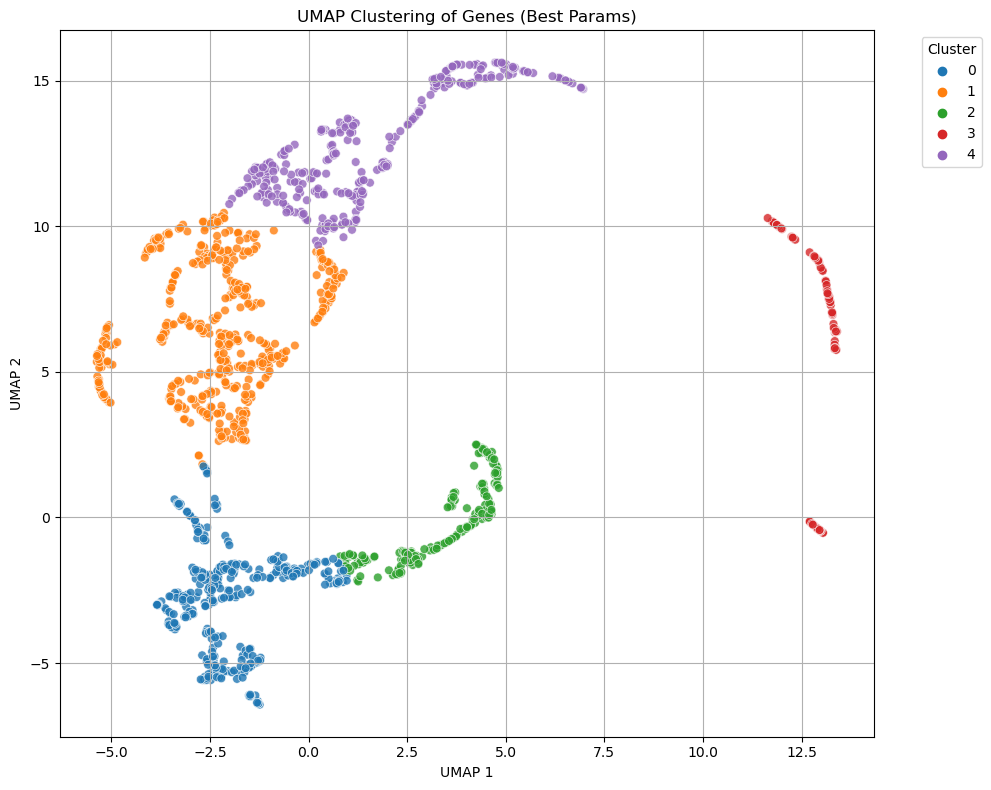

In [11]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='UMAP1', y='UMAP2',
    hue='Cluster',
    palette='tab10',
    data=umap_df,
    s=40,
    alpha=0.8
)
plt.title("UMAP Clustering of Genes (Best Params)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Clustering Optimization

In [13]:
df = pd.read_csv("umap_best_clustering.csv")
X_umap = df[['UMAP1', 'UMAP2']].values
gene_ids = df['GeneID']

In [14]:
best_k = 56
best_init = 'k-means++'
best_n_init = 10

kmeans_model = KMeans(
    n_clusters=best_k,
    init=best_init,
    n_init=best_n_init,
    random_state=42
)
labels = kmeans_model.fit_predict(X_umap)

In [15]:
df['Cluster'] = labels.astype(str)
df['Cluster (int)'] = labels

In [16]:
sil_score = silhouette_score(X_umap, labels)
calinski_score = calinski_harabasz_score(X_umap, labels)
davies_score = davies_bouldin_score(X_umap, labels)

print("Clustering Quality Scores:")
print(f"Silhouette Score       : {sil_score:.3f}")
print(f"Calinski-Harabasz Score: {calinski_score:.3f}")
print(f"Davies-Bouldin Score   : {davies_score:.3f}")

Clustering Quality Scores:
Silhouette Score       : 0.544
Calinski-Harabasz Score: 11328.499
Davies-Bouldin Score   : 0.606


In [17]:
print("\nNumber of genes per cluster:")
print(df['Cluster'].value_counts().sort_index())


Number of genes per cluster:
Cluster
0     33
1     29
10    13
11    38
12    26
13    13
14    20
15    28
16    31
17    33
18    26
19    46
2     26
20    27
21    24
22    18
23    39
24    28
25    17
26    37
27    36
28    21
29    37
3     15
30    19
31    34
32    19
33    27
34    24
35    18
36    37
37    28
38    36
39    46
4     19
40    34
41    33
42    34
43    34
44    25
45    18
46    34
47    24
48    31
49    25
5     19
50    36
51    24
52    23
53    27
54    29
55    32
6     30
7     43
8     22
9     25
Name: count, dtype: int64


In [18]:
df[['GeneID', 'Cluster']].to_csv("kmeans_final_gene_clusters.csv", index=False)

C:\Users\Admin\AppData\Local\Temp\ipykernel_128812\921672706.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


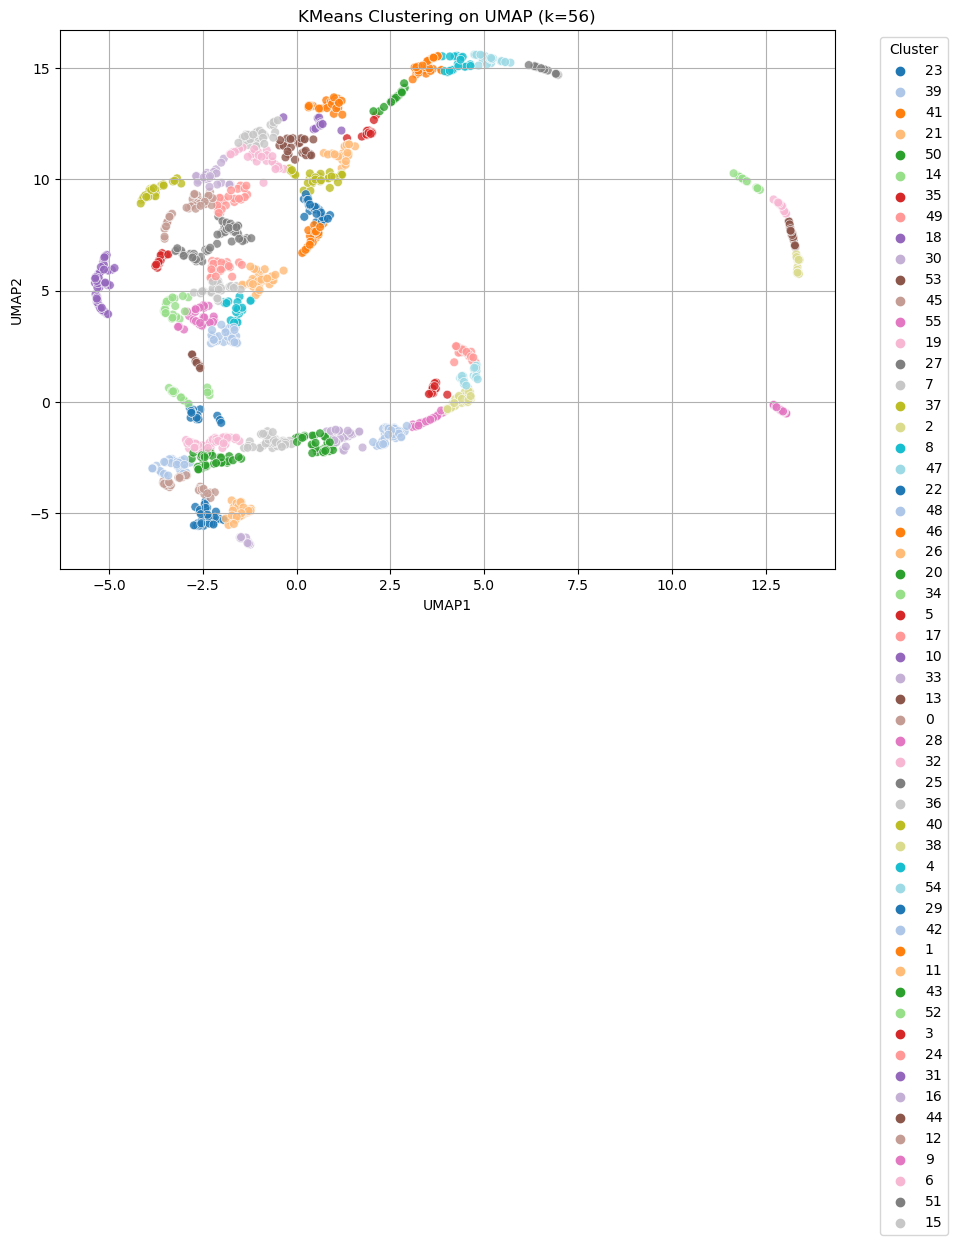

In [19]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='UMAP1', y='UMAP2',
    hue='Cluster',
    palette='tab20',
    data=df,
    s=40,
    alpha=0.8
)
plt.title(f"KMeans Clustering on UMAP (k={best_k})")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

## Biological analysis

In [21]:
df_clusters = pd.read_csv("kmeans_final_gene_clusters.csv")

In [22]:
output_dir = "gprofiler_results_kmeans_clusters"
os.makedirs(output_dir, exist_ok=True)

In [23]:
gp = GProfiler(return_dataframe=True)

In [24]:
unique_clusters = df_clusters['Cluster'].unique()
print(f"🔍 Running g:Profiler for {len(unique_clusters)} KMeans clusters...")

for cluster_id in sorted(unique_clusters):
    gene_list = df_clusters[df_clusters['Cluster'] == cluster_id]['GeneID'].tolist()
    
    if len(gene_list) < 3:
        print(f"⚠️ Skipping KMeans cluster {cluster_id} (only {len(gene_list)} genes)")
        continue

    # Run g:Profiler
    results = gp.profile(
        organism='dmelanogaster',
        query=gene_list,
        user_threshold=1.0,         # return all terms, even non-significant
        no_evidences=False
    )

    # Save unfiltered results
    result_file = os.path.join(output_dir, f"kmeans_cluster_{cluster_id}_enrichment_full.csv")
    results.to_csv(result_file, index=False)

    # Save only significant results (p < 0.05)
    significant = results[results['p_value'] < 0.05]
    sig_file = os.path.join(output_dir, f"kmeans_cluster_{cluster_id}_enrichment_significant.csv")
    significant.to_csv(sig_file, index=False)

    print(f"✅ KMeans Cluster {cluster_id}: {len(significant)} significant terms")
    print(f"   ↳ Full results      → {result_file}")
    print(f"   ↳ Significant only → {sig_file}")

🔍 Running g:Profiler for 56 KMeans clusters...
✅ KMeans Cluster 0: 2 significant terms
   ↳ Full results      → gprofiler_results_kmeans_clusters\kmeans_cluster_0_enrichment_full.csv
   ↳ Significant only → gprofiler_results_kmeans_clusters\kmeans_cluster_0_enrichment_significant.csv
✅ KMeans Cluster 1: 0 significant terms
   ↳ Full results      → gprofiler_results_kmeans_clusters\kmeans_cluster_1_enrichment_full.csv
   ↳ Significant only → gprofiler_results_kmeans_clusters\kmeans_cluster_1_enrichment_significant.csv
✅ KMeans Cluster 2: 0 significant terms
   ↳ Full results      → gprofiler_results_kmeans_clusters\kmeans_cluster_2_enrichment_full.csv
   ↳ Significant only → gprofiler_results_kmeans_clusters\kmeans_cluster_2_enrichment_significant.csv
✅ KMeans Cluster 3: 2 significant terms
   ↳ Full results      → gprofiler_results_kmeans_clusters\kmeans_cluster_3_enrichment_full.csv
   ↳ Significant only → gprofiler_results_kmeans_clusters\kmeans_cluster_3_enrichment_significant.csv
✅

### Top Enriched Terms Across Clusters (Heatmap)

In [25]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob

In [26]:
enrichment_dir = "gprofiler_results_kmeans_clusters"
all_files = glob(f"{enrichment_dir}/kmeans_cluster_*_enrichment_significant.csv")

term_data = []

In [27]:
for file_path in all_files:
    cluster_id = int(os.path.basename(file_path).split('_')[2])
    df = pd.read_csv(file_path)

    # Skip empty results
    if df.empty:
        continue

    for _, row in df.iterrows():
        term = row['name']
        pval = row['p_value']
        term_data.append({
            'Cluster': cluster_id,
            'Term': term,
            'p_value': pval
        })

In [28]:
df_terms = pd.DataFrame(term_data)

In [29]:
df_terms['-log10(p)'] = -np.log10(df_terms['p_value'])

In [30]:
heatmap_data = df_terms.pivot_table(index='Term', columns='Cluster', values='-log10(p)', aggfunc='min')

In [31]:
top_terms = df_terms['Term'].value_counts().head(30).index
heatmap_data = heatmap_data.loc[heatmap_data.index.isin(top_terms)]

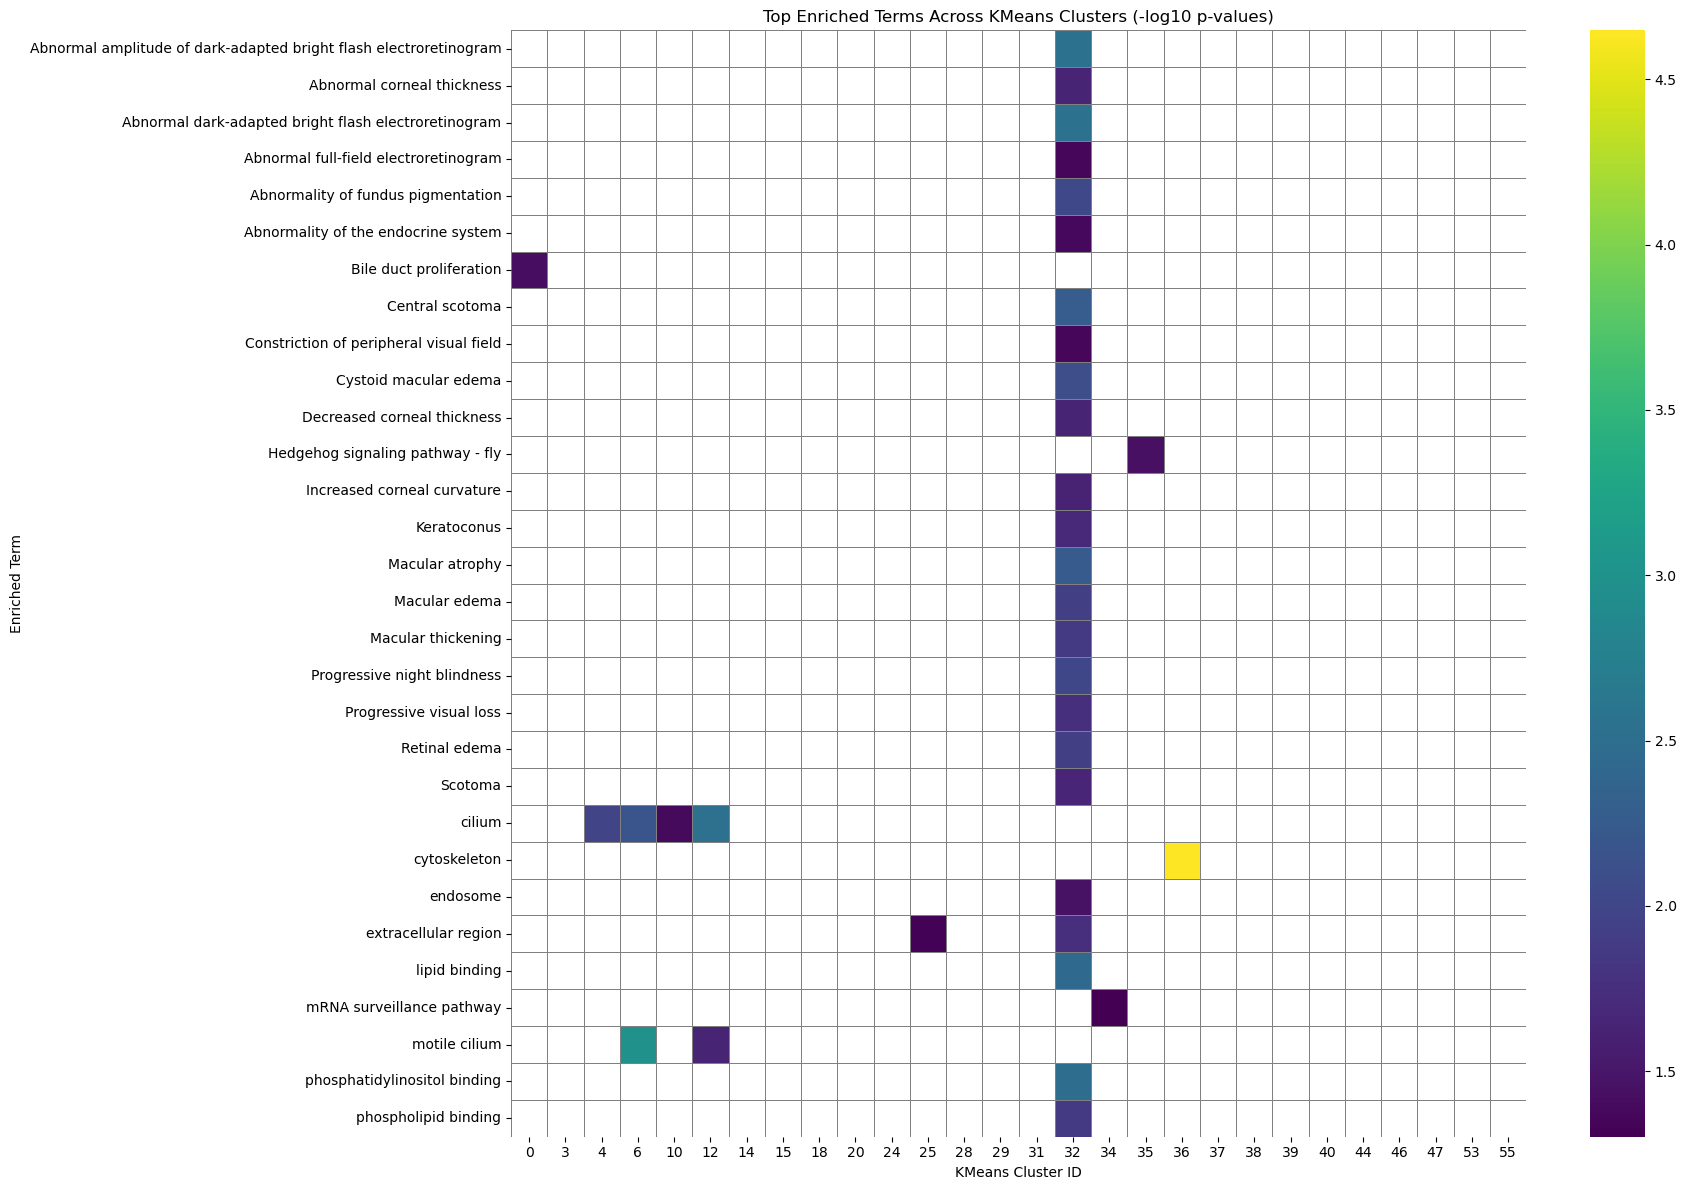

In [32]:
plt.figure(figsize=(18, 12))
sns.heatmap(heatmap_data, cmap='viridis', linewidths=0.5, linecolor='gray', annot=False)
plt.title("Top Enriched Terms Across KMeans Clusters (-log10 p-values)")
plt.xlabel("KMeans Cluster ID")
plt.ylabel("Enriched Term")
plt.tight_layout()
plt.show()

In [33]:
# Save the heatmap data to CSV
heatmap_data.to_csv("top_terms_kmeans_heatmap.csv")

In [34]:
# Gene list for Cluster 32
genes = [
    "FBgn0039098", "FBgn0037782", "FBgn0053966", "FBgn0262007", "FBgn0052282",
    "FBgn0015033", "FBgn0053965", "FBgn0036320", "FBgn0034736", "FBgn0033048",
    "FBgn0011556", "FBgn0050339", "FBgn0034318", "FBti0019220", "FBgn0031248",
    "FBgn0051636", "FBgn0031406", "FBgn0031930", "FBgn0053532"
]

In [35]:
results = gp.profile(
    organism='dmelanogaster',
    query=genes,
    user_threshold=0.05,
    sources=['GO:MF', 'GO:BP', 'GO:CC', 'KEGG'],
    no_evidences=False,
    domain_scope='known'  
)

In [36]:
results.to_csv("cluster32_gprofiler_results.csv", index=False)
print("✅ Cluster 32 enrichment results saved to 'cluster32_gprofiler_results.csv'")

✅ Cluster 32 enrichment results saved to 'cluster32_gprofiler_results.csv'


### Enriched Terms by source (Bar plot)

In [38]:
def plot_terms_by_source(file, cluster_id, top_n=10):
    df = pd.read_csv(file)

    # Calculate -log10(padj) and sort by source and significance
    df['-log10(padj)'] = -np.log10(df['p_value'])
    
    # Limit number of terms per source
    top_terms = df.groupby('source').apply(lambda x: x.nsmallest(top_n, 'p_value')).reset_index(drop=True)

    # Sort by source for grouped barplot layout
    top_terms['source'] = top_terms['source'].astype(str)
    top_terms = top_terms.sort_values(['source', 'p_value'], ascending=[True, True])

    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=top_terms,
        y='name',
        x='-log10(padj)',
        hue='source',
        dodge=False,
        palette='Set2'
    )
    plt.title(f"Cluster {cluster_id} - Enriched Terms Grouped by Source")
    plt.xlabel('-log10(adjusted p-value)')
    plt.ylabel('Enriched Term')
    plt.legend(title='GO/KEGG Source', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

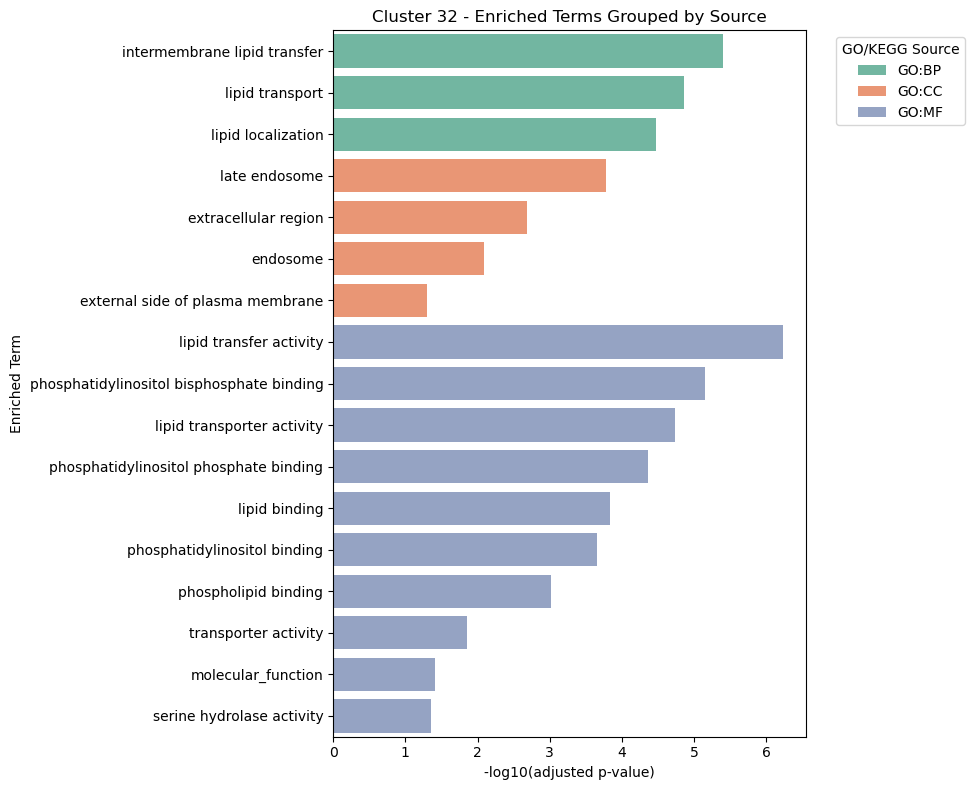

In [39]:
plot_terms_by_source("cluster32_gprofiler_results.csv", 32)

### Protein-Protein Interaction (STRING)

In [41]:
genes_query = '%0d%0a'.join(genes)

In [42]:
url = f"https://string-db.org/api/tsv/network?identifiers={genes_query}&species=7227"  # '7227' is D. melanogaster ID
response = requests.get(url)

In [43]:
if response.status_code == 200:
    # Read the returned data as a DataFrame using StringIO to handle the response text
    interaction_data = pd.read_csv(StringIO(response.text), sep="\t")
    print(interaction_data.head())
else:
    print("Error fetching data from STRING.")

         stringId_A        stringId_B preferredName_A preferredName_B  \
0  7227.FBpp0077481  7227.FBpp0079138           Send1          CG7025   
1  7227.FBpp0079138  7227.FBpp0081680          CG7025           Npc2d   
2  7227.FBpp0079138  7227.FBpp0087260          CG7025         zetaTry   
3  7227.FBpp0081680  7227.FBpp0087260           Npc2d         zetaTry   
4  7227.FBpp0087617  7227.FBpp0310404         CG30339         CG31636   

   ncbiTaxonId  score  nscore  fscore  pscore  ascore  escore  dscore  tscore  
0         7227  0.437       0       0   0.000   0.000   0.102     0.0   0.399  
1         7227  0.698       0       0   0.000   0.675   0.000     0.0   0.111  
2         7227  0.893       0       0   0.000   0.831   0.102     0.0   0.357  
3         7227  0.801       0       0   0.000   0.801   0.045     0.0   0.000  
4         7227  0.426       0       0   0.084   0.000   0.000     0.4   0.000  


In [44]:
G = nx.from_pandas_edgelist(interaction_data, 'stringId_A', 'stringId_B', ['score'])

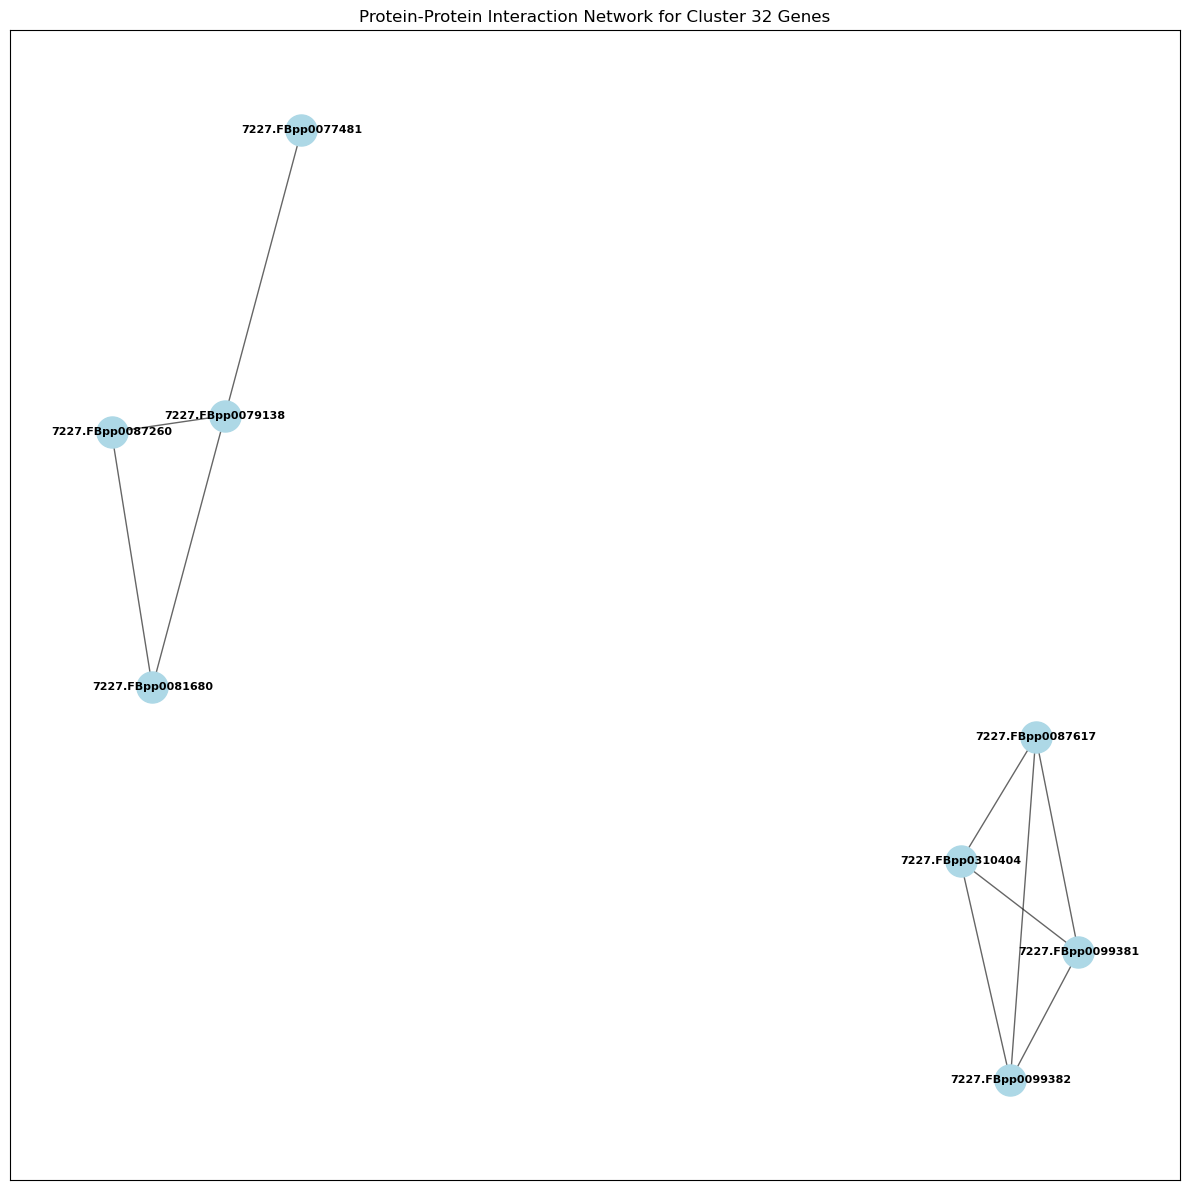

In [45]:
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G)  # layout for nodes
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')
nx.draw_networkx_edges(G, pos, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', font_color='black')

plt.title("Protein-Protein Interaction Network for Cluster 32 Genes")
plt.tight_layout()
plt.show()

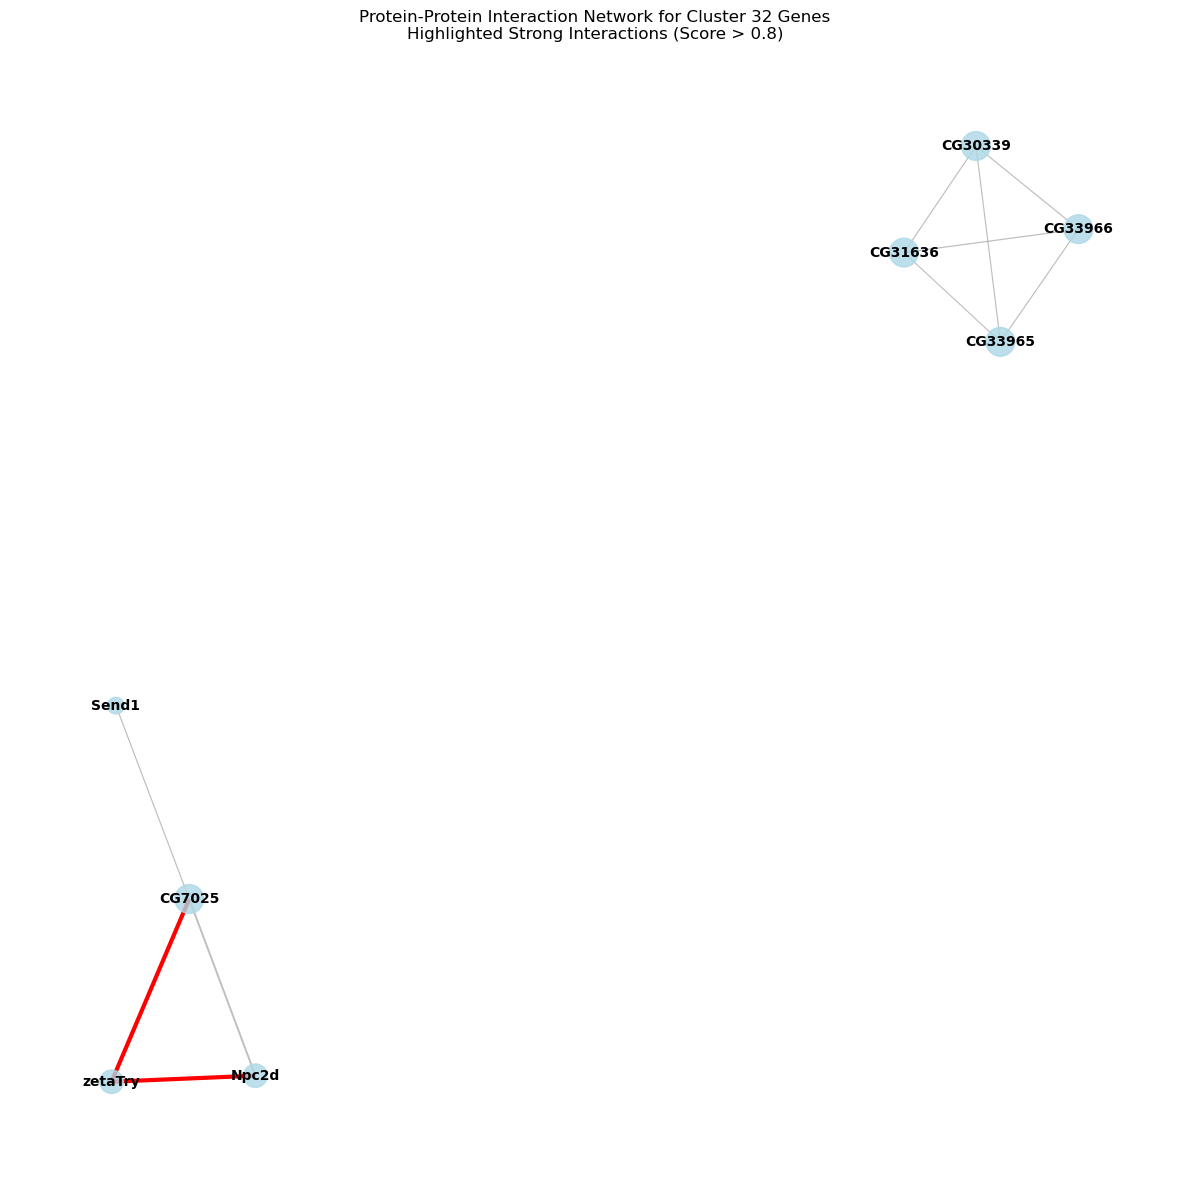

In [46]:
G = nx.from_pandas_edgelist(interaction_data, 'preferredName_A', 'preferredName_B', ['score'])
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

high_score_edges = [(u, v) for u, v, d in G.edges(data=True) if d['score'] > 0.8]
node_sizes = [1000 * degree_centrality[node] for node in G.nodes()]
edge_widths = [2 * G[u][v]['score'] for u, v in G.edges()]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.15, iterations=20)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5, edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=high_score_edges, width=3, edge_color='red')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='black')
plt.title("Protein-Protein Interaction Network for Cluster 32 Genes\nHighlighted Strong Interactions (Score > 0.8)")
plt.axis('off')  # Turn off the axis
plt.tight_layout()
plt.show()

### Volcano plot of all genes 

In [48]:
deseq_df = pd.read_csv("ControlvsAb42_Deseq_output_unfiltered.csv")
deseq_df = deseq_df.rename(columns={'Unnamed: 0': 'GeneID'})

In [49]:
deseq_df['in_cluster'] = deseq_df['GeneID'].isin(genes)

In [50]:
deseq_df['neg_log10_padj'] = -np.log10(deseq_df['padj'])

In [51]:
padj_threshold = 0.05
log2fc_threshold = 1

def classify_gene(row):
    if pd.isna(row['padj']):
        return 'Not Significant'
    if row['padj'] < padj_threshold and abs(row['log2FoldChange']) > log2fc_threshold:
        return 'In Cluster & Significant' if row['in_cluster'] else 'Significant Only'
    return 'Not Significant'

deseq_df['category'] = deseq_df.apply(classify_gene, axis=1)

In [52]:
total_genes = len(deseq_df)
significant_genes = deseq_df[deseq_df['category'].isin(['In Cluster & Significant', 'Significant Only'])].shape[0]

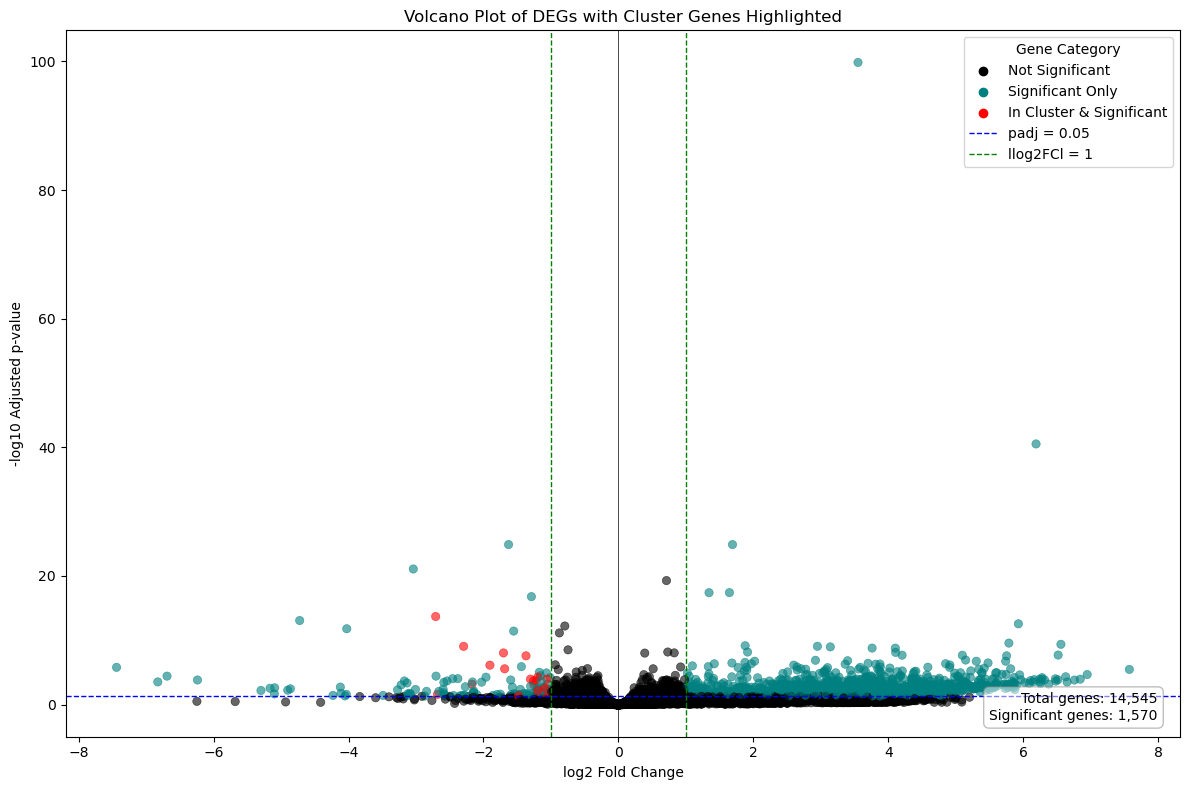

In [53]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=deseq_df,
    x='log2FoldChange',
    y='neg_log10_padj',
    hue='category',
    palette={
        'In Cluster & Significant': 'red',
        'Significant Only': 'teal',
        'Not Significant': 'black'
    },
    alpha=0.6,
    edgecolor=None
)

plt.text(
    0.98, 0.02,
    f"Total genes: {total_genes:,}\nSignificant genes: {significant_genes:,}",
    horizontalalignment='right',
    verticalalignment='bottom',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.5)
)

plt.axhline(y=-np.log10(padj_threshold), color='blue', linestyle='--', linewidth=1, label='padj = 0.05')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.axvline(x=log2fc_threshold, color='green', linestyle='--', linewidth=1, label='llog2FCl = 1')
plt.axvline(x=-log2fc_threshold, color='green', linestyle='--', linewidth=1)

plt.title('Volcano Plot of DEGs with Cluster Genes Highlighted')
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10 Adjusted p-value')
plt.legend(title='Gene Category')
plt.tight_layout()
plt.show()

### Cross-species ortholog mapping 

In [55]:
file_path = 'dmel_human_orthologs_disease_fb_2025_02.tsv'
orthologs_df = pd.read_csv(file_path, sep='\t', skiprows=4, dtype=str)

In [56]:
orthologs_df.rename(columns={'##Dmel_gene_ID': 'Dmel_gene_ID'}, inplace=True)

In [57]:
orthologs_df.columns = orthologs_df.columns.str.strip()

In [58]:
filtered_df = orthologs_df[orthologs_df['Dmel_gene_ID'].isin(genes)]

columns_of_interest = [
    'Dmel_gene_ID',
    'Dmel_gene_symbol',
    'Human_gene_HGNC_ID',
    'Human_gene_OMIM_ID',
    'Human_gene_symbol',
    'DIOPT_score',
    'OMIM_Phenotype_IDs',
    'OMIM_Phenotype_IDs[name]'
]

filtered_df = filtered_df[columns_of_interest]

filtered_df.to_csv('fly_human_orthologs_filtered.csv', index=False)

print(f"Filtered orthologs saved to 'fly_human_orthologs_filtered.csv'")
print(filtered_df.head(10))

Filtered orthologs saved to 'fly_human_orthologs_filtered.csv'
     Dmel_gene_ID Dmel_gene_symbol Human_gene_HGNC_ID Human_gene_OMIM_ID  \
2289  FBgn0034736              gas         HGNC:26741                NaN   
2290  FBgn0034736              gas           HGNC:108         MIM:100740   
2291  FBgn0034736              gas           HGNC:983         MIM:177400   
2292  FBgn0034736              gas         HGNC:26459         MIM:618678   
2293  FBgn0034736              gas          HGNC:1863         MIM:114835   
2294  FBgn0034736              gas          HGNC:1848         MIM:114840   
2295  FBgn0034736              gas          HGNC:1864         MIM:605278   
2296  FBgn0034736              gas          HGNC:1865         MIM:605279   
2297  FBgn0034736              gas         HGNC:14291         MIM:600568   
2298  FBgn0034736              gas         HGNC:14289         MIM:300336   

     Human_gene_symbol DIOPT_score OMIM_Phenotype_IDs  \
2289             CES4A           8         

In [59]:
filtered_df = pd.read_csv('fly_human_orthologs_filtered.csv')

In [60]:
filtered_df['has_disease'] = filtered_df['OMIM_Phenotype_IDs[name]'].notna()

In [61]:
gene_disease_summary = filtered_df.groupby('Dmel_gene_ID')['has_disease'].any().reset_index()
gene_disease_summary['disease_status'] = gene_disease_summary['has_disease'].map({True: 'Has Disease', False: 'No Disease'})

print("Summary of FlyBase genes with disease associations:")
print(gene_disease_summary['disease_status'].value_counts())

Summary of FlyBase genes with disease associations:
disease_status
Has Disease    12
No Disease      3
Name: count, dtype: int64


In [62]:
simplified_df = filtered_df[['Dmel_gene_ID', 'Human_gene_symbol', 'OMIM_Phenotype_IDs[name]']].copy()

In [63]:
simplified_df.to_csv('flybase_human_disease_simplified.csv', index=False)
print("\nSimplified table saved to 'flybase_human_disease_simplified.csv'")


Simplified table saved to 'flybase_human_disease_simplified.csv'


In [64]:
def count_diseases(disease_str):
    if pd.isna(disease_str):
        return 0
    else:
        # Diseases are comma-separated in the string (sometimes with brackets)
        return len(disease_str.split(','))

disease_counts = filtered_df.groupby('Dmel_gene_ID')['OMIM_Phenotype_IDs[name]'].apply(
    lambda x: sum(count_diseases(d) for d in x)
).reset_index(name='disease_count')

In [65]:
disease_counts = disease_counts.merge(gene_disease_summary[['Dmel_gene_ID', 'disease_status']], on='Dmel_gene_ID')

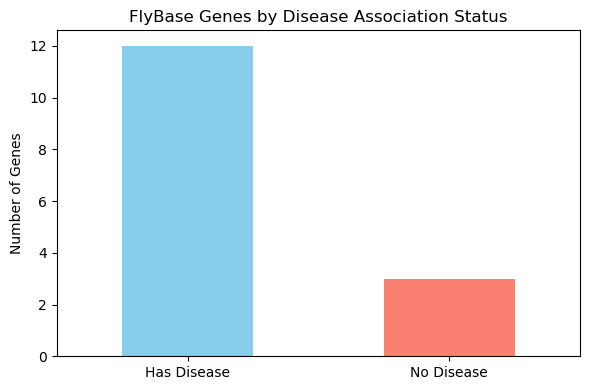

In [66]:
plt.figure(figsize=(6,4))
gene_disease_summary['disease_status'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('FlyBase Genes by Disease Association Status')
plt.ylabel('Number of Genes')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

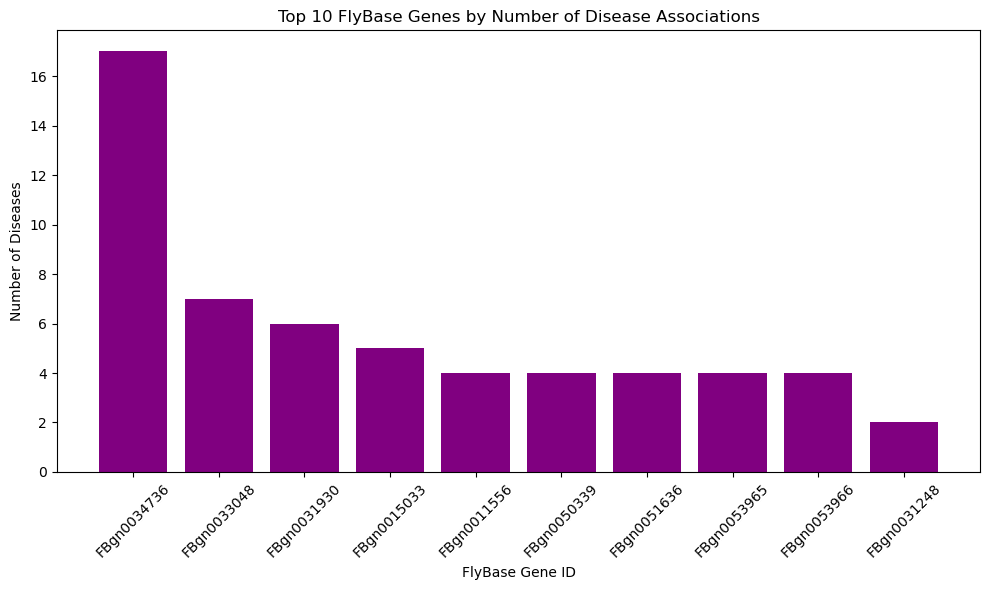

In [67]:
top10 = disease_counts.sort_values(by='disease_count', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['Dmel_gene_ID'], top10['disease_count'], color='purple')
plt.title('Top 10 FlyBase Genes by Number of Disease Associations')
plt.ylabel('Number of Diseases')
plt.xlabel('FlyBase Gene ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Continue with "03_LMC_Complexity_Analysis.R" for Complexity Analysis